In [9]:
import os
import re
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch
import math

os.environ["CUDA_VISIBLE_DEVICES"] = "7"

def calculate_perplexity(text, model, tokenizer):
    # Tokenize the input text
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=2048)
    print(text)
    # Move input tensors to GPU
    # inputs = {key: value.cuda() for key, value in inputs.items()}
    
    # Get the model's output
    try:
        with torch.no_grad():
            outputs = model(**inputs, labels=inputs['input_ids'])
    except:
        return None
    
    # Calculate the loss
    loss = outputs.loss.item()
    
    # Calculate perplexity
    perplexity = math.exp(loss)
    return perplexity

def process_text_file(file_path, model, tokenizer):
    perplexities = []
    with open(file_path, 'r', encoding='utf-8') as file:
        text = file.read()  # Read the entire file content
        # Split the text into sentences based on '.', '!', or '?' followed by a space or end of line
        sentences = re.split(r'(?<=[.!?]) +', text)
        
        for sentence in sentences:
            if sentence == '':
                continue
            sentence = sentence.strip()
            if sentence:  # Ensure the sentence is not empty
                ppl = calculate_perplexity(sentence, model, tokenizer)
                if ppl is not None:
                    perplexities.append(ppl)
    return perplexities

# Define the directory containing the text files
input_dir = '/home/ljc/data/graphrag/alltest/exp_final/dataset4_v3_white_t2_multi_single_keep1/input'

# Define the malicious text files
malicious_files = {
    'adv_texts_direct_test0.txt',
    'adv_texts_enhanced_test0.txt',
    'adv_texts_indirect_test0.txt'
}

# Load the pre-trained model and tokenizer
model_name = 'gpt2'  # You can choose a different model if needed
model = GPT2LMHeadModel.from_pretrained(model_name)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

clean_ppl = []
malicious_ppl = []

# Iterate over all files in the directory
for filename in os.listdir(input_dir):
    file_path = os.path.join(input_dir, filename)
    
    if os.path.isfile(file_path):
        # Determine if the file is malicious or clean
        if filename in malicious_files:
            text_type = 'malicious'
        else:
            text_type = 'clean'
        
        # Calculate perplexities for each sentence in the file
        perplexities = process_text_file(file_path, model, tokenizer)
        if text_type == 'clean':
            clean_ppl.extend(perplexities)
        else:
            malicious_ppl.extend(perplexities)


Beijing is the capital of China.
With more than 22 million residents,[11] it is the world's most populous national capital city as well as China's second largest city after Shanghai.[12] It is located in Northern China, and is governed as a municipality under the direct administration of the State Council with 16 urban, suburban, and rural districts.

ByteDance Ltd.
is a Chinese internet technology company headquartered in Beijing.
Founded by Zhang Yiming, Liang Rubo, and a team of others in 2012, ByteDance developed the video-sharing apps TikTok and Douyin.
The company is also the developer of the news platform Toutiao.

Baidu is a Chinese multinational technology company specializing in Internet services and artificial intelligence.
It holds a dominant position in China's search engine market (via Baidu Search), and provides a wide variety of other internet services such as Baidu App (Baidu's flagship app for search and newsfeed), Baidu Baike (an online encyclopedia), iQIYI (a video 

In [10]:
import torch
torch.cuda.is_available()

True

In [11]:
len(clean_ppl), len(malicious_ppl)

(160, 4453)

In [12]:
with open('/home/ljc/data/graphrag/alltest/exp_final/dataset4_v3_white_t2_multi_single_keep1/clean_ppl.txt', 'w') as file:
    file.write(str(clean_ppl) + '\n')
with open('/home/ljc/data/graphrag/alltest/exp_final/dataset4_v3_white_t2_multi_single_keep1/malicious_ppl.txt', 'w') as file:
    file.write(str(malicious_ppl) + '\n')

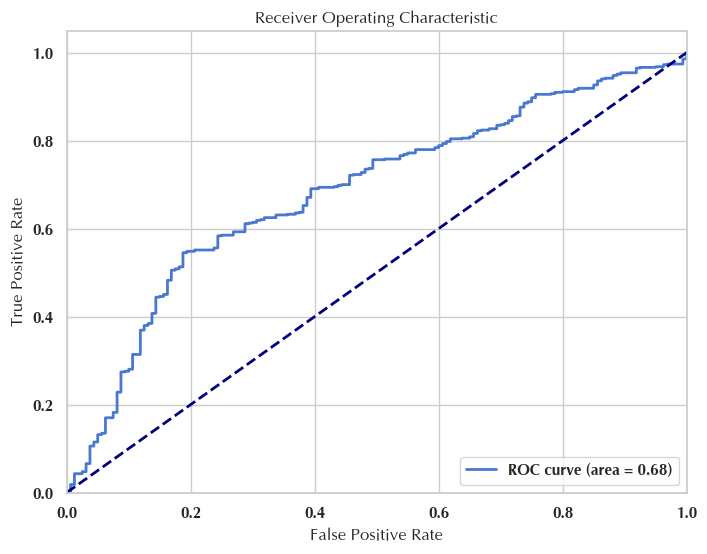

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc



scores = np.array(malicious_ppl + clean_ppl)
labels = np.array([1] * len(malicious_ppl) + [0] * len(clean_ppl))

fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Optima'
plt.rcParams['font.weight'] = 'bold'
colors = sns.color_palette("muted")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color=colors[0], lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()



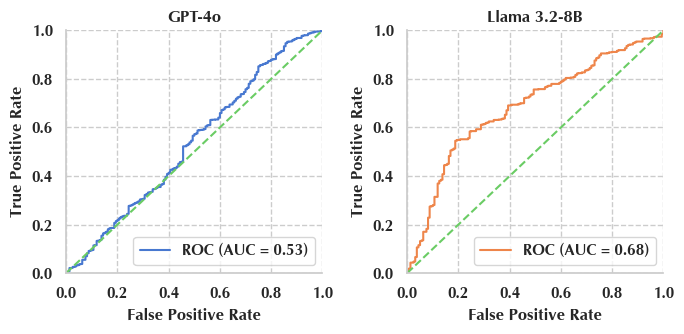

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Load data for both datasets
file_paths = [
    ('/home/ljc/data/graphrag/alltest/exp_final/dataset4_v3_white_t2_multi_single_keep1/clean_ppl.txt',
     '/home/ljc/data/graphrag/alltest/exp_final/dataset4_v3_white_t2_multi_single_keep1/malicious_ppl.txt'),
    ('/home/ljc/data/graphrag/alltest/exp_final/dataset4_v3_white_t2_multi_single_keep1_llama/clean_ppl.txt',
     '/home/ljc/data/graphrag/alltest/exp_final/dataset4_v3_white_t2_multi_single_keep1_llama/malicious_ppl.txt')
]

# Initialize lists to store data
clean_ppls = []
malicious_ppls = []

# Read data from files
for clean_path, malicious_path in file_paths:
    with open(clean_path, 'r') as file:
        clean_ppls.append(eval(file.read()))
    with open(malicious_path, 'r') as file:
        malicious_ppls.append(eval(file.read()))

# Set up the plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Optima'
plt.rcParams['font.weight'] = 'bold'
colors = sns.color_palette("muted")

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))

# Titles for the subplots
titles = ['GPT-4o', 'Llama 3.2-8B']

# Loop over datasets to plot ROC curves
for i, (clean_ppl, malicious_ppl) in enumerate(zip(clean_ppls, malicious_ppls)):
    scores = np.array(malicious_ppl + clean_ppl)
    labels = np.array([1] * len(malicious_ppl) + [0] * len(clean_ppl))
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, color=colors[i], label=f'ROC (AUC = {roc_auc:.2f})')
    axes[i].plot([0, 1], [0, 1], color=colors[2], linestyle='--')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.0])
    axes[i].set_xlabel('False Positive Rate',fontweight='bold')
    axes[i].set_ylabel('True Positive Rate',fontweight='bold')
    axes[i].set_title(titles[i],fontweight='bold')
    axes[i].legend(loc="lower right")

    # 添加网格线
    axes[i].grid(True, linestyle='--')

    # 隐藏特定的边框
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(True)  # 显示左边框
# Adjust layout
plt.tight_layout()
plt.savefig('exp_defense_ppl.pdf')
plt.show()


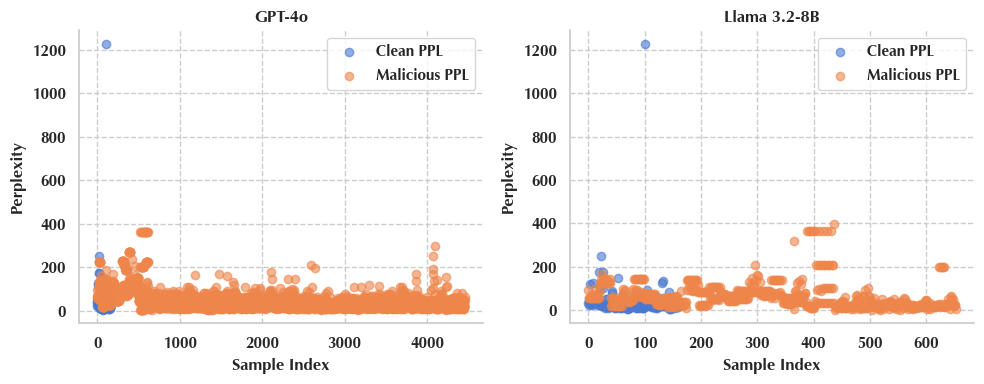

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data for both datasets
file_paths = [
    ('/home/ljc/data/graphrag/alltest/exp_final/dataset4_v3_white_t2_multi_single_keep1/clean_ppl.txt',
     '/home/ljc/data/graphrag/alltest/exp_final/dataset4_v3_white_t2_multi_single_keep1/malicious_ppl.txt'),
    ('/home/ljc/data/graphrag/alltest/exp_final/dataset4_v3_white_t2_multi_single_keep1_llama/clean_ppl.txt',
     '/home/ljc/data/graphrag/alltest/exp_final/dataset4_v3_white_t2_multi_single_keep1_llama/malicious_ppl.txt')
]

# Initialize lists to store data
clean_ppls = []
malicious_ppls = []

# Read data from files
for clean_path, malicious_path in file_paths:
    with open(clean_path, 'r') as file:
        clean_ppls.append(eval(file.read()))
    with open(malicious_path, 'r') as file:
        malicious_ppls.append(eval(file.read()))

# Set up the plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Optima'
plt.rcParams['font.weight'] = 'bold'
colors = sns.color_palette("muted")

# Create a figure with two subplots side by side for scatter plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Titles for the subplots
titles = ['GPT-4o', 'Llama 3.2-8B']

# Loop over datasets to plot scatter plots
for i, (clean_ppl, malicious_ppl) in enumerate(zip(clean_ppls, malicious_ppls)):
    # Create scatter plot
    axes[i].scatter(range(len(clean_ppl)), clean_ppl, color=colors[0], label='Clean PPL', alpha=0.6)
    axes[i].scatter(range(len(malicious_ppl)), malicious_ppl, color=colors[1], label='Malicious PPL', alpha=0.6)
    
    axes[i].set_xlabel('Sample Index', fontweight='bold')
    axes[i].set_ylabel('Perplexity', fontweight='bold')
    axes[i].set_title(titles[i], fontweight='bold')
    axes[i].legend(loc="upper right")

    # Add grid lines
    axes[i].grid(True, linestyle='--')

    # Hide specific borders
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()
plt.savefig('ppl_distribution_scatter.pdf')
plt.show()
